# Stage 2B cap-sensitivity comparison

Compare global-module discovery at candidate caps **10, 15, and 20**, with semantic rho fixed at **0.90**.

This notebook is lightweight: it only reads prepared Stage 2B outputs, reviews candidate and support-filter counts, compares k diagnostics, and quantifies module stability across caps.

In [17]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.optimize import linear_sum_assignment

MODULE_DIR = Path('/projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules')
UTILS_PATH = MODULE_DIR / 'stage2_global_module_utils_v7.py'

import importlib.util, sys
spec = importlib.util.spec_from_file_location('stage2_global_module_utils_compare', UTILS_PATH)
gm = importlib.util.module_from_spec(spec)
sys.modules['stage2_global_module_utils_compare'] = gm
spec.loader.exec_module(gm)

SENS_ROOT = Path('/projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v8/stage2b_cap_sensitivity')
PREPARED_ROOTS = {
    10: SENS_ROOT / 'prepared' / 'cap010__rho0p9',
    15: SENS_ROOT / 'prepared' / 'cap015__rho0p9',
    20: SENS_ROOT / 'prepared' / 'cap020__rho0p9',
}
PANELS = ['AR', 'BT']

PREPARED_ROOTS

{10: PosixPath('/projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v8/stage2b_cap_sensitivity/prepared/cap010__rho0p9'),
 15: PosixPath('/projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v8/stage2b_cap_sensitivity/prepared/cap015__rho0p9'),
 20: PosixPath('/projects/ovcare/users/nikolay_alabi/immuno/stage2_global_modules_v8/stage2b_cap_sensitivity/prepared/cap020__rho0p9')}

## 1. Completion audit

In [18]:
audit_rows = []
for cap, root in PREPARED_ROOTS.items():
    for panel in PANELS:
        pdir = root / panel
        required = [
            pdir / f'{panel}_consensus_similarity.parquet',
            pdir / f'{panel}_consensus_similarity_support_filtered.parquet',
            pdir / f'{panel}_k_selection_diagnostics.csv',
            pdir / f'{panel}_memberships_all_k.csv',
        ]
        audit_rows.append({
            'cap': cap,
            'panel': panel,
            'root_exists': root.exists(),
            'panel_dir_exists': pdir.exists(),
            'all_required_exist': all(x.exists() for x in required),
            'missing': '; '.join(str(x) for x in required if not x.exists()),
        })

audit = pd.DataFrame(audit_rows)
display(audit)
assert audit['all_required_exist'].all(), 'One or more prepared outputs are incomplete.'
print('All cap/panel outputs are complete.')

,cap,panel,root_exists,panel_dir_exists,all_required_exist,missing
0,10,AR,True,True,True,
1,10,BT,True,True,True,
2,15,AR,True,True,True,
3,15,BT,True,True,True,
4,20,AR,True,True,True,
5,20,BT,True,True,True,


All cap/panel outputs are complete.


## 2. Load prepared results

In [19]:
prepared = {}
for cap, root in PREPARED_ROOTS.items():
    prepared[cap] = {}
    for panel in PANELS:
        prepared[cap][panel] = gm.load_prepared_panel(root, panel)
        obj = prepared[cap][panel]
        print(
            f'cap={cap:>2} panel={panel} | '
            f'consensus={obj["consensus"].shape} | '
            f'support_filtered={obj["consensus_filtered"].shape} | '
            f'kdiag={obj["k_diagnostics"].shape}'
        )

cap=10 panel=AR | consensus=(87, 87) | support_filtered=(87, 87) | kdiag=(22, 23)
cap=10 panel=BT | consensus=(89, 89) | support_filtered=(89, 89) | kdiag=(17, 23)
cap=15 panel=AR | consensus=(127, 127) | support_filtered=(127, 127) | kdiag=(22, 23)
cap=15 panel=BT | consensus=(125, 125) | support_filtered=(125, 125) | kdiag=(17, 23)
cap=20 panel=AR | consensus=(159, 159) | support_filtered=(159, 159) | kdiag=(22, 23)
cap=20 panel=BT | consensus=(160, 160) | support_filtered=(160, 160) | kdiag=(17, 23)


## 3. Candidate and support-filter summary

In [20]:
summary_rows = []
for cap in PREPARED_ROOTS:
    for panel in PANELS:
        obj = prepared[cap][panel]
        fs = obj['feature_support_summary'].copy()
        kd = obj['k_diagnostics'].copy()
        best = kd.sort_values('k_composite_score', ascending=False, na_position='last').iloc[0] if not kd.empty else pd.Series(dtype=float)
        summary_rows.append({
            'cap': cap,
            'panel': panel,
            'n_manifest_features': int(obj['manifest_used']['feature_uid'].nunique()),
            'n_consensus_features': int(obj['consensus'].shape[0]),
            'n_support_filtered_features': int(obj['consensus_filtered'].shape[0]),
            'support_retention_fraction': (obj['consensus_filtered'].shape[0] / obj['consensus'].shape[0]) if obj['consensus'].shape[0] else np.nan,
            'best_k_by_composite': int(best.get('requested_k')) if len(best) else np.nan,
            'best_composite_score': best.get('k_composite_score', np.nan),
            'best_stat_silhouette': best.get('stat_silhouette', np.nan),
            'best_primitive_silhouette': best.get('primitive_semantic_silhouette', np.nan),
            'best_singleton_fraction': best.get('singleton_fraction', np.nan),
            'best_max_cluster_fraction': best.get('max_cluster_fraction', np.nan),
        })

cap_summary = pd.DataFrame(summary_rows).sort_values(['panel', 'cap'])
display(cap_summary)

,cap,panel,n_manifest_features,n_consensus_features,n_support_filtered_features,support_retention_fraction,best_k_by_composite,best_composite_score,best_stat_silhouette,best_primitive_silhouette,best_singleton_fraction,best_max_cluster_fraction
0,10,AR,87,87,87,1.0,19,0.896591,0.467745,-0.360939,0.421053,0.321839
2,15,AR,127,127,127,1.0,21,0.796591,0.441818,-0.411626,0.428571,0.267717
4,20,AR,159,159,159,1.0,18,0.786364,0.347644,-0.298854,0.166667,0.496855
1,10,BT,89,89,89,1.0,10,0.851471,0.339088,-0.269843,0.200000,0.382022
3,15,BT,125,125,125,1.0,17,0.800000,0.467874,-0.340190,0.294118,0.264000
5,20,BT,160,160,160,1.0,10,0.780882,0.388371,-0.259121,0.200000,0.500000


In [21]:
print("PANELS:", PANELS)
print("cap_summary shape:", cap_summary.shape)
print("columns:", cap_summary.columns.tolist())

print("\nPanels present:")
print(cap_summary["panel"].value_counts(dropna=False))

print("\nCap values:")
print(sorted(cap_summary["cap"].dropna().unique()))

display(cap_summary.head(10))

PANELS: ['AR', 'BT']
cap_summary shape: (6, 12)
columns: ['cap', 'panel', 'n_manifest_features', 'n_consensus_features', 'n_support_filtered_features', 'support_retention_fraction', 'best_k_by_composite', 'best_composite_score', 'best_stat_silhouette', 'best_primitive_silhouette', 'best_singleton_fraction', 'best_max_cluster_fraction']

Panels present:
AR    3
BT    3
Name: panel, dtype: int64

Cap values:
[10, 15, 20]


,cap,panel,n_manifest_features,n_consensus_features,n_support_filtered_features,support_retention_fraction,best_k_by_composite,best_composite_score,best_stat_silhouette,best_primitive_silhouette,best_singleton_fraction,best_max_cluster_fraction
0,10,AR,87,87,87,1.0,19,0.896591,0.467745,-0.360939,0.421053,0.321839
2,15,AR,127,127,127,1.0,21,0.796591,0.441818,-0.411626,0.428571,0.267717
4,20,AR,159,159,159,1.0,18,0.786364,0.347644,-0.298854,0.166667,0.496855
1,10,BT,89,89,89,1.0,10,0.851471,0.339088,-0.269843,0.200000,0.382022
3,15,BT,125,125,125,1.0,17,0.800000,0.467874,-0.340190,0.294118,0.264000
5,20,BT,160,160,160,1.0,10,0.780882,0.388371,-0.259121,0.200000,0.500000


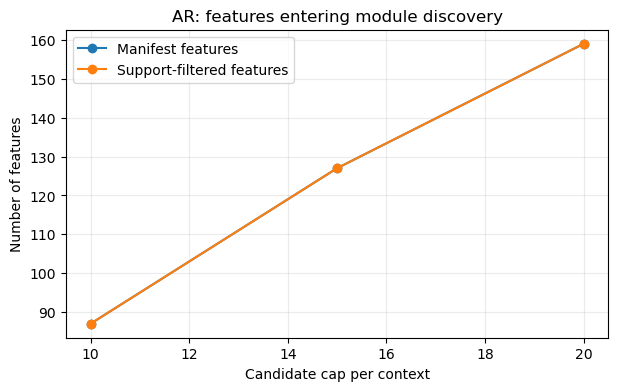

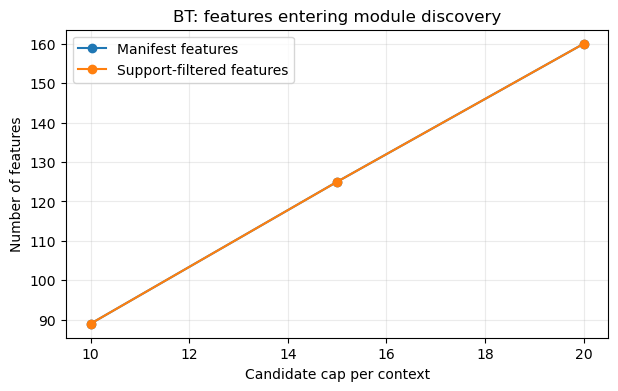

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
for panel in PANELS:
    sub = cap_summary[cap_summary['panel'].eq(panel)].copy()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(sub['cap'], sub['n_manifest_features'], marker='o', label='Manifest features')
    ax.plot(sub['cap'], sub['n_support_filtered_features'], marker='o', label='Support-filtered features')
    ax.set_xlabel('Candidate cap per context')
    ax.set_ylabel('Number of features')
    ax.set_title(f'{panel}: features entering module discovery')
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()

## 4. Compare k-selection curves

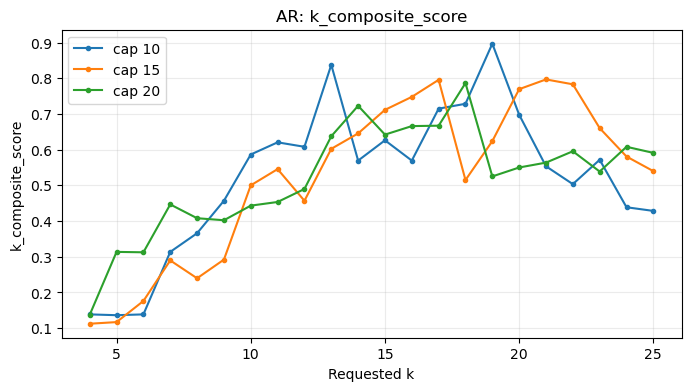

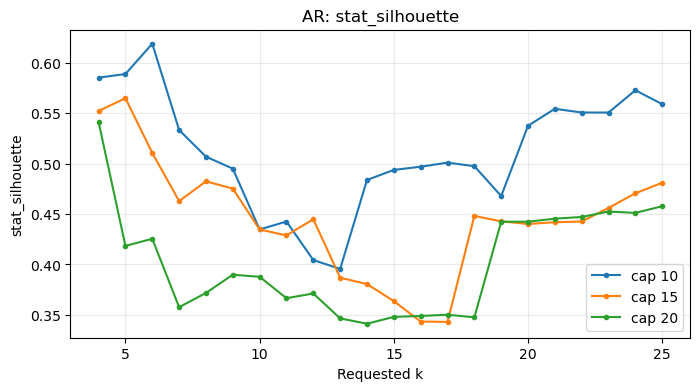

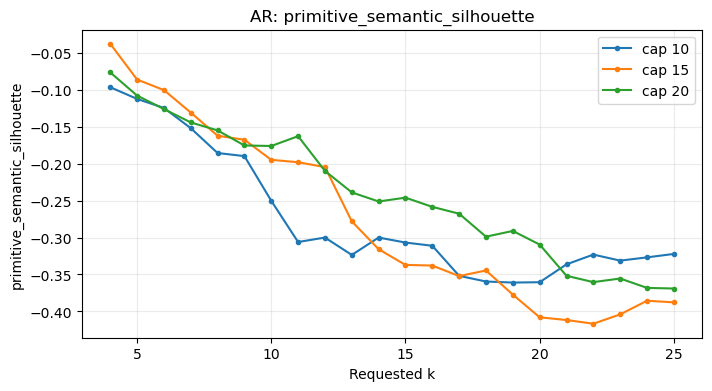

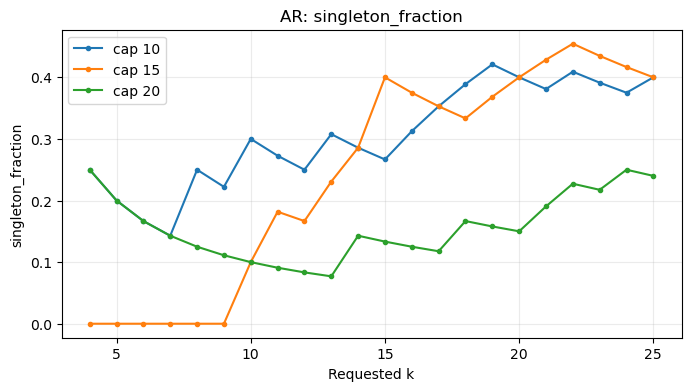

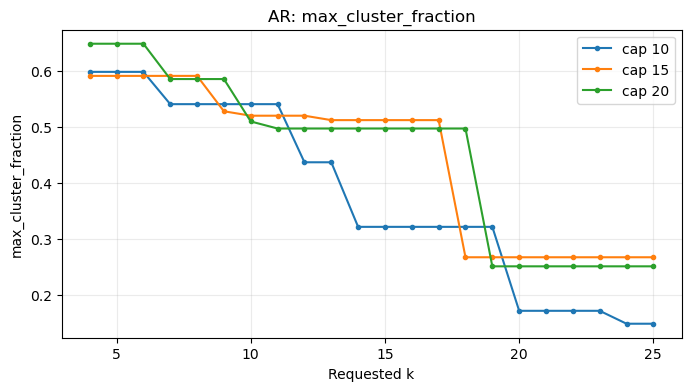

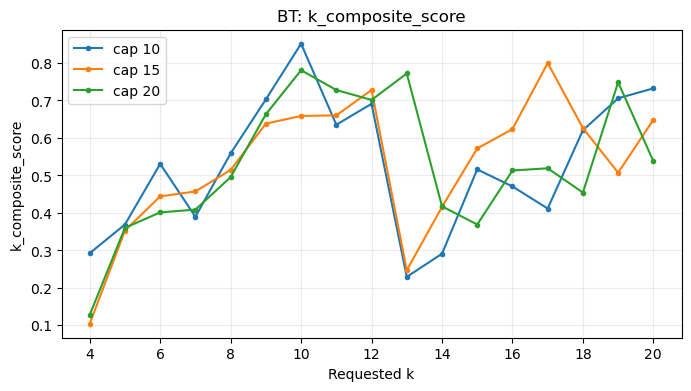

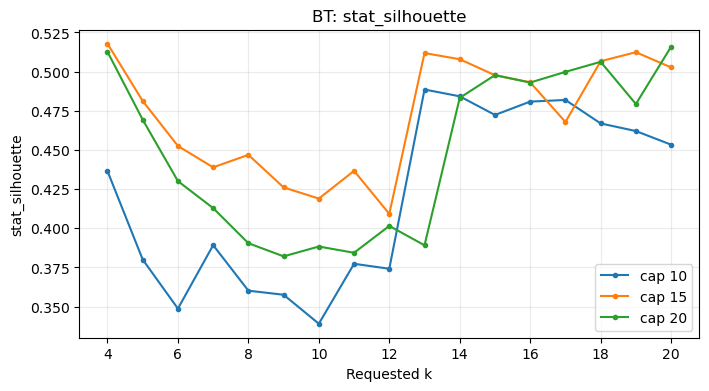

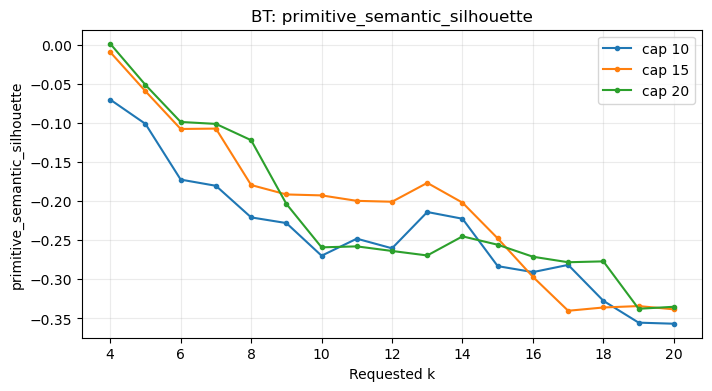

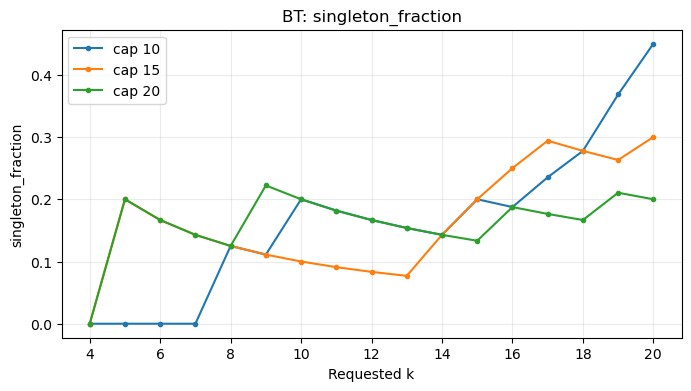

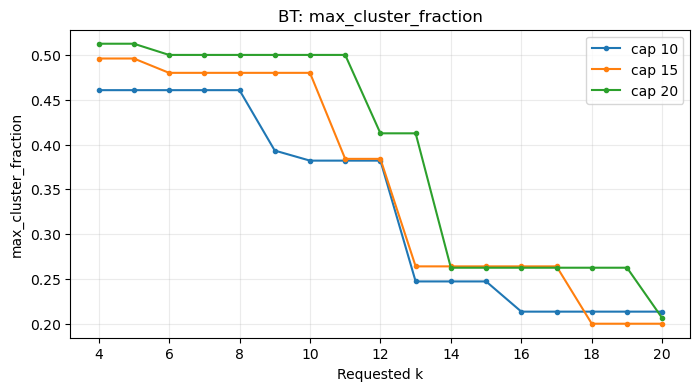

In [23]:
metrics_to_plot = [
    'k_composite_score',
    'stat_silhouette',
    'primitive_semantic_silhouette',
    'singleton_fraction',
    'max_cluster_fraction',
]

for panel in PANELS:
    for metric in metrics_to_plot:
        fig, ax = plt.subplots(figsize=(8, 4))
        for cap in sorted(PREPARED_ROOTS):
            kd = prepared[cap][panel]['k_diagnostics'].sort_values('requested_k')
            if metric in kd.columns:
                ax.plot(kd['requested_k'], kd[metric], marker='o', markersize=3, label=f'cap {cap}')
        ax.set_xlabel('Requested k')
        ax.set_ylabel(metric)
        ax.set_title(f'{panel}: {metric}')
        ax.legend()
        ax.grid(alpha=0.25)
        plt.show()

## 5. Shortlist plausible k values for each cap

In [16]:
shortlist_parts = []
for cap in sorted(PREPARED_ROOTS):
    for panel in PANELS:
        short = gm.make_k_shortlist(prepared[cap][panel]['k_diagnostics'], top_n=6).copy()
        short.insert(0, 'panel', panel)
        short.insert(0, 'cap', cap)
        shortlist_parts.append(short)

k_shortlist = pd.concat(shortlist_parts, ignore_index=True, sort=False)
display(k_shortlist)

,cap,panel,requested_k,k_composite_score,stat_silhouette,primitive_semantic_silhouette,tissue_aware_semantic_silhouette,max_cluster_fraction,singleton_fraction,median_cluster_size,within_95pct_best_composite
0,10,AR,19,0.896591,0.467745,-0.360939,-0.256788,0.321839,0.421053,2.0,True
1,10,AR,13,0.837500,0.395550,-0.323538,-0.251392,0.436782,0.307692,3.0,False
2,10,AR,18,0.728409,0.497381,-0.359535,-0.246995,0.321839,0.388889,2.5,False
3,10,AR,17,0.714773,0.500855,-0.351831,-0.251478,0.321839,0.352941,3.0,False
4,10,AR,20,0.697727,0.537388,-0.360478,-0.255713,0.172414,0.400000,2.5,False
5,10,AR,15,0.626136,0.493640,-0.306788,-0.230218,0.321839,0.266667,3.0,False
6,10,BT,10,0.851471,0.339088,-0.269843,-0.220519,0.382022,0.200000,4.0,True
7,10,BT,20,0.732353,0.453375,-0.356749,-0.228441,0.213483,0.450000,2.0,False
8,10,BT,19,0.705882,0.462076,-0.355373,-0.229980,0.213483,0.368421,2.0,False
9,10,BT,9,0.702941,0.357579,-0.228096,-0.202673,0.393258,0.111111,4.0,False


## 6. Choose one provisional k per cap and panel

Use the diagnostic curves, heatmaps, singleton fraction, and module-size balance. These choices are provisional and are used only to compare cap stability.

In [ ]:
# EDIT AFTER REVIEWING THE DIAGNOSTICS.
CHOSEN_K = {
    10: {'AR': None, 'BT': None},
    15: {'AR': None, 'BT': None},
    20: {'AR': None, 'BT': None},
}
CHOSEN_K

## 7. Preview module summaries for the provisional k values

In [ ]:
module_objects = {}
module_summary_parts = []
for cap, panel_map in CHOSEN_K.items():
    module_objects[cap] = {}
    for panel, k in panel_map.items():
        if k is None:
            continue
        obj = prepared[cap][panel]
        mem = gm.remap_modules_by_size(obj['memberships_all_k'], int(k))
        summ = gm.summarize_modules(
            membership=mem,
            manifest=obj['manifest_used'],
            consensus_filtered=obj['consensus_filtered'],
            pair_support_filtered=obj['pair_support_filtered'],
            ontology_df=obj['ontology'],
        )
        module_objects[cap][panel] = {'membership': mem, 'summary': summ}
        s = summ.copy()
        s.insert(0, 'panel', panel)
        s.insert(0, 'cap', cap)
        module_summary_parts.append(s)
        print(f'\ncap={cap} panel={panel} k={k}')
        display(summ)

module_summary_all = pd.concat(module_summary_parts, ignore_index=True, sort=False) if module_summary_parts else pd.DataFrame()

In [ ]:
if not module_summary_all.empty:
    module_quality = (
        module_summary_all.groupby(['cap', 'panel'], as_index=False)
        .agg(
            n_modules=('module_id', 'nunique'),
            n_features=('n_features', 'sum'),
            median_module_size=('n_features', 'median'),
            max_module_size=('n_features', 'max'),
            singleton_fraction=('n_features', lambda x: float((x == 1).mean())),
            mean_abs_consensus_corr=('mean_abs_consensus_corr', 'mean'),
            mean_pair_support=('mean_pair_support', 'mean'),
        )
    )
    module_quality['largest_module_fraction'] = module_quality['max_module_size'] / module_quality['n_features']
    display(module_quality)

## 8. Cross-cap module stability on shared features

In [ ]:
def membership_map(mem):
    return mem.drop_duplicates('feature_uid').set_index('feature_uid')['module_id'].astype(str)

def coclustering_agreement(a, b):
    common = sorted(set(a.index) & set(b.index))
    if len(common) < 2:
        return np.nan, len(common)
    la = a.loc[common].to_numpy()
    lb = b.loc[common].to_numpy()
    ia, ja = np.triu_indices(len(common), k=1)
    same_a = la[ia] == la[ja]
    same_b = lb[ia] == lb[ja]
    return float(np.mean(same_a == same_b)), len(common)

def best_module_jaccard(a, b):
    common = sorted(set(a.index) & set(b.index))
    if not common:
        return np.nan, pd.DataFrame()
    a = a.loc[common]
    b = b.loc[common]
    mods_a = sorted(a.unique())
    mods_b = sorted(b.unique())
    J = np.zeros((len(mods_a), len(mods_b)))
    for i, ma in enumerate(mods_a):
        set_a = set(a.index[a.eq(ma)])
        for j, mb in enumerate(mods_b):
            set_b = set(b.index[b.eq(mb)])
            union = set_a | set_b
            J[i, j] = len(set_a & set_b) / len(union) if union else 0.0
    row_ind, col_ind = linear_sum_assignment(-J)
    matches = pd.DataFrame({
        'module_a': [mods_a[i] for i in row_ind],
        'module_b': [mods_b[j] for j in col_ind],
        'jaccard': [J[i, j] for i, j in zip(row_ind, col_ind)],
    })
    return float(matches['jaccard'].mean()) if len(matches) else np.nan, matches

stability_rows = []
match_tables = {}
for panel in PANELS:
    for cap_a, cap_b in combinations(sorted(CHOSEN_K), 2):
        if panel not in module_objects.get(cap_a, {}) or panel not in module_objects.get(cap_b, {}):
            continue
        a = membership_map(module_objects[cap_a][panel]['membership'])
        b = membership_map(module_objects[cap_b][panel]['membership'])
        common = sorted(set(a.index) & set(b.index))
        ari = adjusted_rand_score(a.loc[common], b.loc[common]) if len(common) >= 2 else np.nan
        nmi = normalized_mutual_info_score(a.loc[common], b.loc[common]) if len(common) >= 2 else np.nan
        coclust, n_common = coclustering_agreement(a, b)
        mean_j, matches = best_module_jaccard(a, b)
        match_tables[(panel, cap_a, cap_b)] = matches
        stability_rows.append({
            'panel': panel,
            'cap_a': cap_a,
            'cap_b': cap_b,
            'n_shared_features': n_common,
            'adjusted_rand_index': ari,
            'normalized_mutual_info': nmi,
            'pairwise_coclustering_agreement': coclust,
            'mean_best_module_jaccard': mean_j,
        })

stability = pd.DataFrame(stability_rows)
display(stability)

## 9. Inspect provisional heatmaps

In [ ]:
for cap, panel_map in CHOSEN_K.items():
    root = PREPARED_ROOTS[cap]
    for panel, k in panel_map.items():
        if k is None:
            continue
        plot_path = root / 'plots' / panel / f'{panel}_consensus_heatmap_k{int(k):02d}.png'
        print(f'cap={cap} panel={panel} k={k}: {plot_path}')
        if plot_path.exists():
            display(Image(filename=str(plot_path)))
        else:
            print('Provisional image not pre-generated for this k; use the existing review notebook or gm.plot_consensus_heatmap.')

## 10. Decision framework

Prefer the **smallest cap** that satisfies all of the following:

- module structure is stable relative to the next larger cap;
- major biological programs are retained;
- singleton and tiny-module burden is acceptable;
- no single module dominates the panel;
- statistical and semantic k diagnostics are not materially worse;
- increasing the cap mainly adds peripheral features rather than stable new modules.

Typical interpretation:

- choose cap 10 if cap 10 and cap 15 recover essentially the same programs;
- choose cap 15 if it adds stable and interpretable programs absent at cap 10;
- choose cap 20 only if those additional features improve module structure rather than fragmenting it.

## 11. Freeze the final selected cap and k values

In [ ]:
# EDIT ONLY AFTER THE COMPARISON IS COMPLETE.
FINAL_CAP = None
FINAL_K = {'AR': None, 'BT': None}

# Example:
# FINAL_CAP = 15
# FINAL_K = {'AR': 14, 'BT': 9}

FINAL_CAP, FINAL_K

In [ ]:
assert FINAL_CAP in PREPARED_ROOTS, 'Set FINAL_CAP to 10, 15, or 20.'
assert all(FINAL_K[p] is not None for p in PANELS), 'Set FINAL_K for AR and BT.'

final_root = PREPARED_ROOTS[FINAL_CAP]
final_results = {}
for panel in PANELS:
    final_results[panel] = gm.finalize_panel_modules(final_root, panel, int(FINAL_K[panel]))

print('Final modules saved under:', final_root / 'final_modules')